# Geeignete Modelle finden

In diesem Notbook werden mehrere Modelle ausprobiert um zu überprüfen welche die besten Vorhersagen auf diesem Datenset tätigen.

## 1. Module importieren und Daten einlesen

In [1]:
# Import what we need

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
# Read the previously splitted Train and Test data
# Features and target were also separated previously

features_train = pd.read_csv('../data/processed/features_train.csv', index_col=0)
features_test = pd.read_csv('../data/processed/features_test.csv', index_col=0)
target_train = pd.read_csv('../data/processed/target_train.csv', index_col=0)
target_test = pd.read_csv('../data/processed/target_test.csv', index_col=0)

# Targets have to be pandas series
target_train = target_train['poisonous']
target_test = target_test['poisonous']

# Load the info data frame as well
side_info = pd.read_csv('../data/processed/side_info.csv', index_col=0)
display(side_info)

,name,role,type,description,nr_of_uniques
0,poisonous,Target,Binary,"0=poisonous, 1=edible",2
1,cap-shape,Feature,Categorical,"bell=b,conical=c,convex=x,flat=f, knobbed=k,su...",6
2,cap-surface,Feature,Categorical,"fibrous=f,grooves=g,scaly=y,smooth=s",4
3,cap-color,Feature,Categorical,"brown=n,buff=b,cinnamon=c,gray=g,green=r, pink...",10
4,bruises,Feature,Binary,"bruises=t,no=f",2
5,odor,Feature,Categorical,"almond=a,anise=l,creosote=c,fishy=y,foul=f, mu...",9
6,gill-attachment,Feature,Categorical,"attached=a,descending=d,free=f,notched=n",2
7,gill-spacing,Feature,Categorical,"close=c,crowded=w,distant=d",2
8,gill-size,Feature,Categorical,"broad=b,narrow=n",2
9,gill-color,Feature,Categorical,"black=k,brown=n,buff=b,chocolate=h,gray=g, gre...",12


## 2. Modelle und Pipeline

Für verschiedene Modelle Pipelines aufbauen und Testen.

Die Vorbereitung der Features mittels ColumnTransformer ist für alle Modelle gleich. Daher wird dieser nur einmal erstellt.

In [3]:
# Differentiate between category cols (for OHE) and binary cols (for OE)
cat_cols = []
bin_cols = []

# go through the side_info
# ignore the first row since it is the target
for i in range(1, side_info.shape[0]):
    si_row = side_info.iloc[i]
    if si_row['type'] == 'Categorical':
        cat_cols.append(si_row['name'])
    elif si_row['type'] == 'Binary':
        bin_cols.append(si_row['name'])
    else:
        print('Something unexpected happened. Check:', si_row['name'])

# create the two encoders we need
oe = OrdinalEncoder()
ohe = OneHotEncoder(sparse_output=False,
                    handle_unknown='warn')

# create the ColumnTransformer with both encoders
encoder = ColumnTransformer([('oe', oe, bin_cols), 
                            ('ohe', ohe, cat_cols)],
                            remainder='drop')

# Although it will be used in a pipeline later,
# here we check how it applies to the training features
transformed_features = encoder.fit_transform(features_train)
feature_names = []
for name, transformer, columns in encoder.transformers_:
    if name == 'oe':
        cnames = columns
    elif name == 'ohe':
        cnames = transformer.get_feature_names_out(columns)
    else:
        print('Error: Check if the encoder was manipulated')
        cnames = -1
    feature_names.extend(cnames)

transformed_features = pd.DataFrame(transformed_features, columns=feature_names)
display(transformed_features.head(10))

,bruises,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 2.1. Logistic Regression

Das erste Modell, dass wir untersuchen ist die Logistische Regression.
Wir starten mit einer Logistischen Regression ohne Regularisierung.

<Axes: >

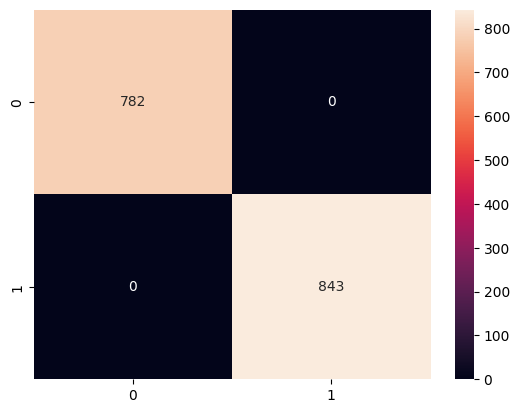

In [4]:
from sklearn.linear_model import LogisticRegression

# create model
logReg = LogisticRegression(solver='saga', penalty=None, max_iter=10000, random_state=42)

# create pipeline
pipe_LogReg = Pipeline([('encoder', encoder),
                        ('model', logReg)])

# train the model
pipe_LogReg.fit(features_train, target_train)

# predict test data
predict_LogReg = pipe_LogReg.predict(features_test)

# Get and display the confusion matrix
conf_matrix = confusion_matrix(target_test, predict_LogReg)
sns.heatmap(conf_matrix, annot=True, fmt='d')

Das unregularisierte Modell hat alle Testdaten perfekt vorhergesagt.
Beeindruckend, aber schauen wir uns dennoch ein regularisiertes Modell zum Vergleich an.
Die besten Parameter sollen mit einer Grid Search gefunden werden. Daher müssen wir verschiedene Parameter vorher definieren.

Das nicht-regularisierte Modell hat uns schon gezeigt, dass alle Pilzsorten perfekt erkannt werden. Aber die regularisierten Modelle
könnten die Sicherheit mit denen die Pilze erkannt werden noch erhöhen. Daher bietet sich der ROC-AUC score als Zielgröße zur Optimierung an.
Außerdem dient der Vergleich zwischen den beiden Modellen auch akademischen Zwecken.

In [5]:
# If the model was already trained and saved previously, run this cell
# and ignore the cell below
model_grid = pickle.load(open('../models/model_grid_logreg.p', 'rb'))

In [6]:
# # Define different parameter
# cvalues = [0.01, 0.1, 0.5, 1, 5, 10, 50, 1000]
# param_grid = {'model__penalty' : ['l1', 'l2'],
#               'model__C' : cvalues}

# # create pipeline
# # Note that regularization needs a scaler
# pipe_LogReg_reg = Pipeline([('encoder', encoder),
#                         ('scaler', StandardScaler()),
#                         ('model', LogisticRegression(solver='saga', 
#                                                      max_iter=10000, 
#                                                      random_state=42))])

# # create the grid search
# model_grid = GridSearchCV(estimator=pipe_LogReg_reg,
#                           param_grid=param_grid,
#                           scoring='roc_auc',
#                           cv=5,
#                           n_jobs=-1)

# # train the model via grid search
# model_grid.fit(features_train, target_train)
# print('Best parameters: ', model_grid.best_params_)
# print('Best score: ', model_grid.best_score_)

# # Since the grid search takes some time, save the model
# # so that we can simply load it if we re-run this notebook
# pickle.dump(model_grid, open('../models/model_grid_logreg.p', 'wb'))

<Axes: >

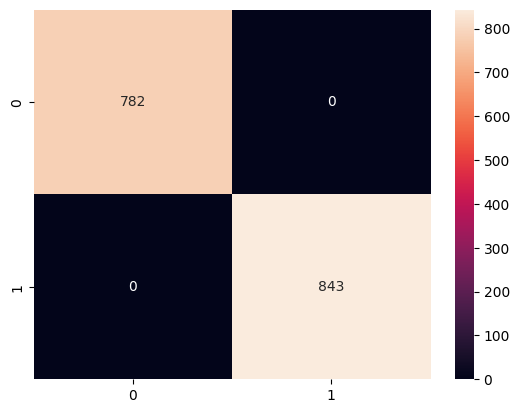

In [7]:
# predict test data
predict_LogReg_reg = model_grid.predict(features_test)

# Get and display the confusion matrix
conf_matrix_reg = confusion_matrix(target_test, predict_LogReg_reg)
sns.heatmap(conf_matrix_reg, annot=True, fmt='d')

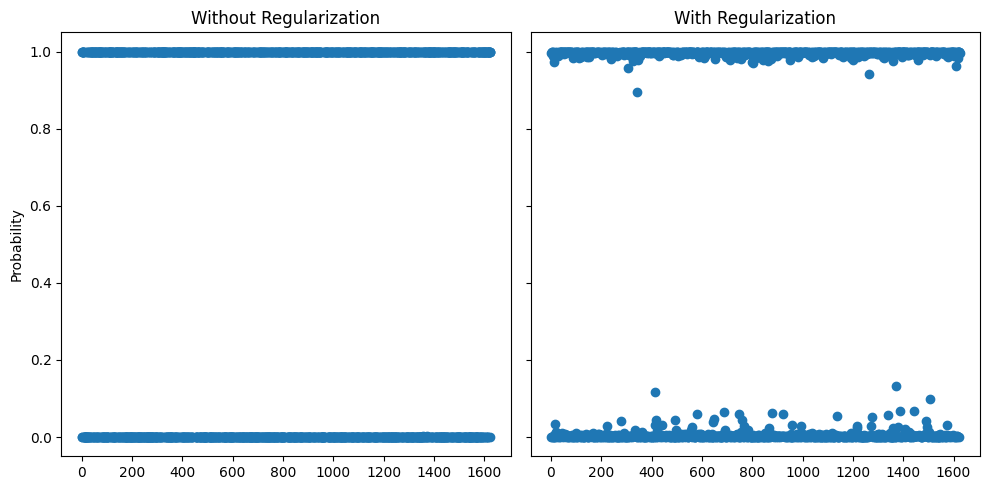

In [8]:
# Let us see how certain the predictions are
proba_test_logReg = pipe_LogReg.predict_proba(features_test)
proba_test_logReg_reg = model_grid.predict_proba(features_test)

# print the probabilities
fig, axs = plt.subplots(ncols=2, sharey=True, figsize=(10,5))
axs[0].scatter(range(len(target_test)), proba_test_logReg[:,0])
axs[0].set_ylabel('Probability')
axs[0].set_title('Without Regularization')
axs[1].scatter(range(len(target_test)), proba_test_logReg_reg[:,0])
axs[1].set_title('With Regularization')
plt.tight_layout()
plt.show()

Wie in der Abbildung zu sehen ist, sagt die unregularisierte Logistische Regression die richtigen Daten mit einer höheren Überzeugung voraus.
Beim Blick auf die genauen Wahrscheinlichkeiten fällt auf, dass es eine wirklich sehr deutliche Vorhersage ist. Die Vorhersagen bei der regularisierten Logistischen Regression sind nicht ganz so perfekt.
Ich vermute hier aber, dass es daran liegt, dass der Datensatz aus künstlich generierten Daten besteht. Die Daten sind "zu perfekt", ohne natürliche Unsicherheiten.

### 2.2. Decision Tree

Hier schauen wir uns den Decision Tree Classifier an. Wenn die Ergebnisse gut sind, können wir daraus sehr viele Erkenntnisse ziehen. Diese werden aber erst später behandelt.

Als erstes schauen wir auf die validation curve ab wann wir einen sehr guten Recall haben.

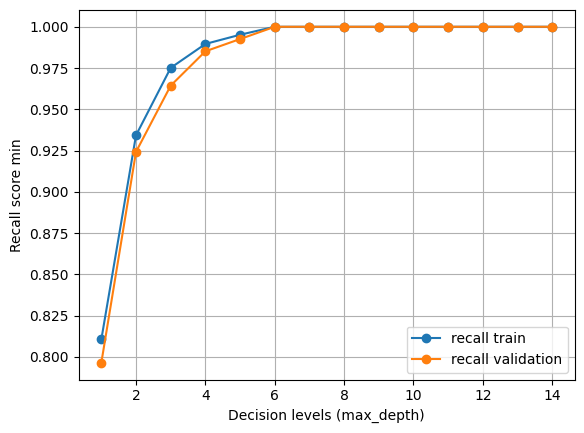

In [9]:
from sklearn.model_selection import validation_curve

# set-up for validation curve: which max_depth-settings to try
search_space = range(1, 15)

# create pipeline
pipe_tree = Pipeline([('encoder', encoder),
                        ('model', DecisionTreeClassifier(random_state=42))])


# calculate recall values of different hyperparameter settings and cross validation folds
recall_train, recall_val = validation_curve(estimator=pipe_tree, 
                                            X=features_train, 
                                            y=target_train, 
                                            param_name='model__max_depth',
                                            param_range=search_space,
                                            cv=5,
                                            scoring='recall')

# calculate minimal recall values for each hyperparameter setting
# one could argue to use the average value, but we want to be sure
recall_train_mean = np.min(recall_train, axis=1)
recall_val_mean = np.min(recall_val, axis=1)

# plot validation curve
fig, ax = plt.subplots()
ax.plot(search_space, recall_train_mean, '-o', label='recall train')
ax.plot(search_space, recall_val_mean, '-o', label='recall validation')
ax.set(xlabel='Decision levels (max_depth)',
       ylabel='Recall score min')
ax.grid()
ax.legend();

Ab einem `max_depth` Wert von 6 kann keine Verbesserung im Recall stattfinden.

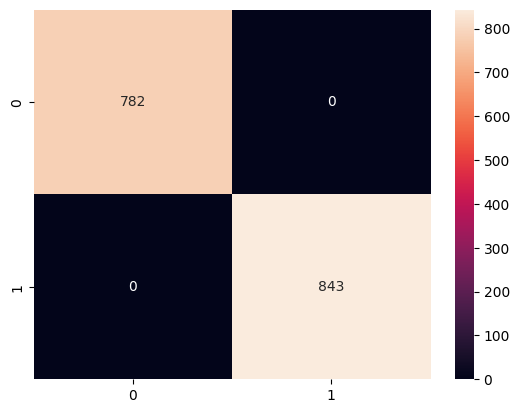

In [10]:
tree = DecisionTreeClassifier(max_depth=6, random_state=42)    # max number of terminal nodes (leafs)
# create pipeline
pipe_tree = Pipeline([('encoder', encoder),
                        ('model', tree)])

# train the model
pipe_tree.fit(features_train, target_train)

# predict test data
predict_tree = pipe_tree.predict(features_test)

# Get and display the confusion matrix
conf_matrix = confusion_matrix(target_test, predict_tree)
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.show()

Ein einzelner Decision Tree ist ausreichend um alle Testdaten perfekt vorherzusagen.

### 2.3 CatBoost

Der Klassifizierer CatBoost damit beworben, dass er mit Kategorischen Features trainieren kann, ohne One-Hot-Encoding zu benötigen.
Das vereinfacht die Handhabung stark. Damit meine ich nicht nur das OneHotEncoding vor dem Trainieren (das geht relativ schnell mit dem ColumnTransformer), sondern das Auswerten der Ergebnisse.

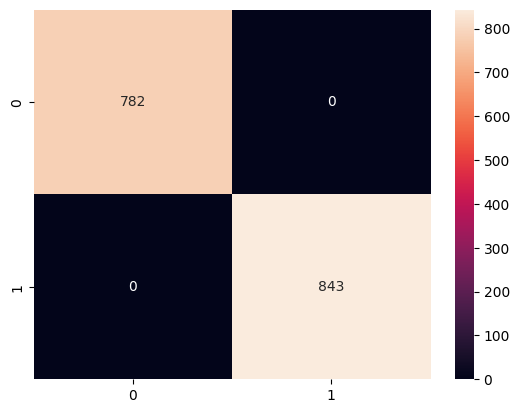

In [11]:
# Construct a model with 100 iterations and a depth of 6 (worked for Decision Tree)
model = CatBoostClassifier(
    iterations=100,      
    cat_features=list(features_train.columns),   
    depth=6,              
    verbose=0             
)

# Train model and make predictions on test data
model.fit(features_train, target_train)
y_pred = model.predict(features_test)

# plot confusion matrix
conf_matrix = confusion_matrix(target_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.show()

Tatsächlich. Das Modell ist schnell trainiert und liefert perfekte Vorhersagen -- ohne dass wir vorher onehotencoden mussten.

Wir können hier schon die ersten Erkenntnisse gewinnen.

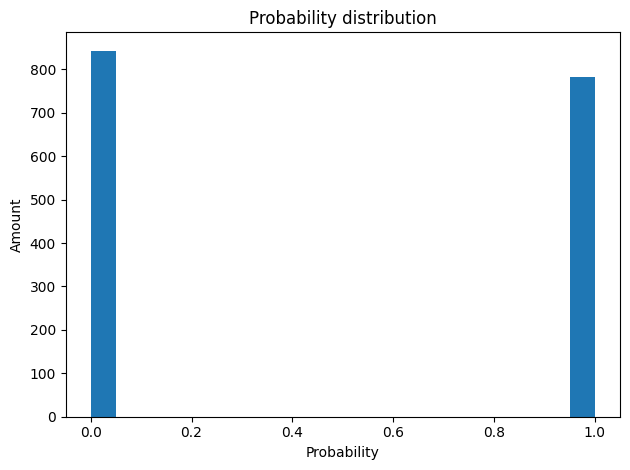

In [12]:
# plot the probality distribution
y_pred_proba = model.predict_proba(features_test)

feat_imp = pd.Series(model.feature_importances_, index=features_train.columns)
feat_imp.plot(kind='barh', ax=axs[0])
plt.hist(y_pred_proba[:,0], bins=20)
plt.xlabel('Probability')
plt.ylabel('Amount')
plt.title('Probability distribution')
plt.tight_layout()
plt.show()

Wir sehen hier eine sehr klare Trennung. Das Model ist sich sehr sicher zu welcher Klasse ein Datenpunkt gehört.

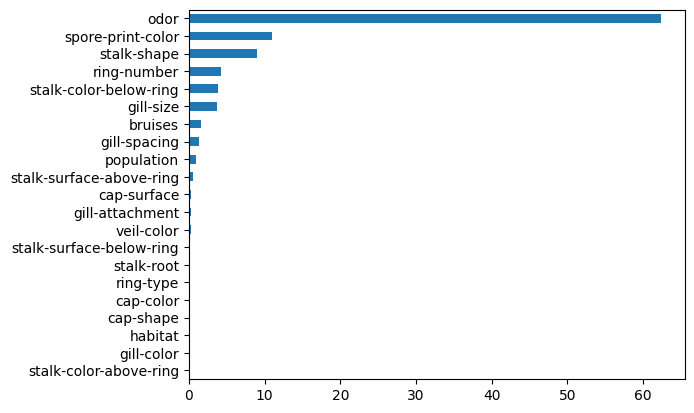

In [13]:
# Look at the feature importance
feat_imp = pd.Series(model.feature_importances_, 
                     index=features_train.columns)
feat_imp.sort_values().plot(kind='barh');

Hier zeigt sich ein großer Vorteil daran, dass der CatBooster kein OneHotEncoding braucht. Wir können uns die Feature Importance direkt anschauen.
Anscheinend ist der Geruch sehr entscheidend.

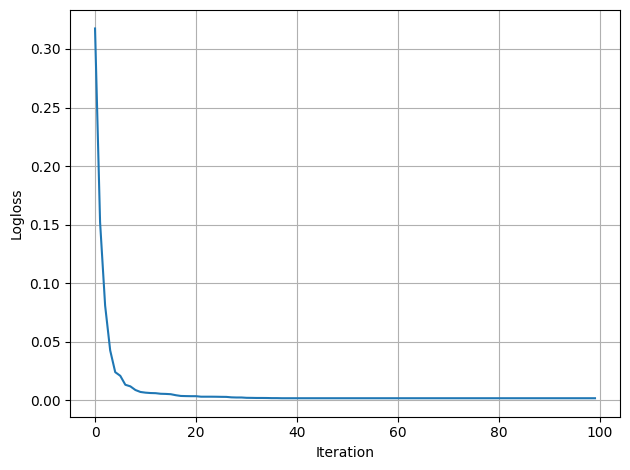

In [14]:
# Plot the loss function
logloss = model.get_evals_result()['learn']['Logloss']
plt.plot(range(100), logloss)
plt.xlabel('Iteration')
plt.ylabel('Logloss')
plt.grid()
plt.tight_layout()
plt.show()

### 2.4 Neural Network

In einem anderen Repository auf meinem Profil habe ich ein Projekt namens `educational-neural-network`. In diesem ist der Aufbau eines neuronalen Netzwerkes erklärt. Zur Veranschaulichung habe ich diese Grundlagen in einem Framework zusammengefasst, dass auch Vorhersagen der Klassifizierung tätigen kann. Auch wenn dieses Projekt rein akademischen Nutzen hat, finde ich es interessant es mit den Mushroom Daten hier zu testen.

Dazu holen wir uns das Netzwerk `network.py` und den Helfer `network_handler.py` von dem Repository und nutzen es als Werkzeuge hier.
Wir bauen damit ein einfaches kleines Netzwerk aus Input- und Outputlayer sowie 3 hidden Layers, die jeweils 6, 6 und 4 Neuronen sowie Bias haben.

e:\Stackfuel_portfolio\Can-I-eat-it\notebooks\network.py:305: SyntaxWarning: invalid escape sequence '\p'
  To ensure an optimal minimization progress, we give the gradient $\frac{\partial J}{\partial \Theta_{ij}}$


# It      Cost Train      Cost Test      
--------- ----------      ----------     
0         6.06593         6.07059        
1         0.00653         0.00618        
2         0.03765         0.02622        
3         0.01199         0.00804        
4         0.009           0.00844        
5         0.01434         0.00867        


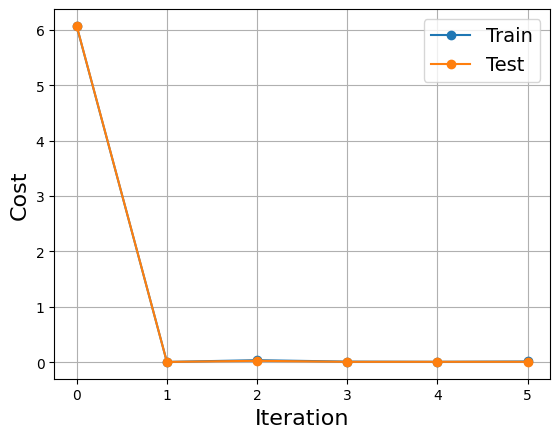

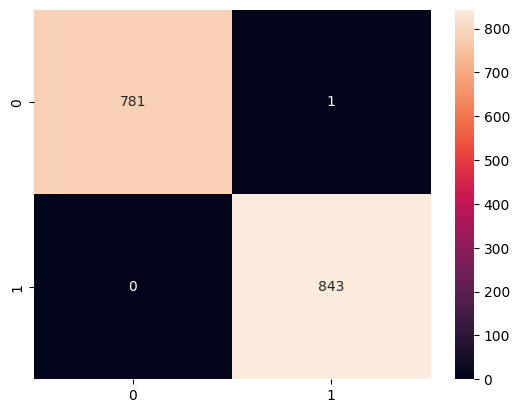

In [15]:
# Import the neural network and the network handler
from network import NeuralNetwork as NN
import network_handler as NH

# define a network architecture
# in this case we use for the hidden layer 6, 6, and 4 neurons each
nn_architecture = [transformed_features.shape[1], 6, 6, 4, 2]

# Create the network
network = NH.create_network(nn_architecture)

# Give the data to the network
# note that the data has to be encoded first
nn_data = encoder.transform(features_train)
data = NH.construct_data(nn_data, target_train.values)

# Split the data into train and cross-val data
train_data, cv_data, dummy_test_data = NH.part_data(data, 
                                    parts=[0.8, 0.2, 0.0],
                                    shuffle=True)

# Train the network with the training data and validate with the cv data
# We use 5 batches, print graphic and text, use a lambda parameter of 0.4
# I think 5 iterations should be sufficient
result = NH.training_with_test(network, train_data, cv_data,
                    nr_batches=5, display='graphic and text',
                    lam=0.4, nr_iterations=5,
                    shuffle=True)

# Make predictions with the test inputs
test_input = encoder.transform(features_test)
test_output = target_test.values
test_pred = NH.make_prediction(network, test_input)

# Now we take a look at the confusion matrix
conf_matrix = confusion_matrix(test_output, test_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.show()

Tatsächlich erreicht auch mein einfaches Übungsmodell eines neuronalen Netzwerkes sehr gute Ergebnisse. Auffällig ist auch, dass die Cost function schon nach einer Iteration sehr gering ist.

## 3. Zusammenfassung

Alle hier verwendeten Modelle erreichen in den ersten Tests, ohne weiter Optimierung perfekte Vorhersagen. Das liegt, meines Erachtens, an den künstlich erstellten Daten.
Die Modelle erlenten schnell die Regeln, die der Datenerschaffung zu Grunde lagen und wendeten sie an. Im nächsten Notebook werden wir uns den Decision Tree Classifier im Detail angucken und damit die Ergebnisse auswerten.